# Galileo Platform Offering - LLMs

In [1]:
from dotenv import load_dotenv
import os
import time
import base64
from IPython.display import display, Image
from pydantic import BaseModel
import json

In [2]:
load_dotenv() # it looks for .env file and then load the configuration to environnment variables

True

The Galileo Platform uses [Portkey](https://galileo-genai.pages.roche.com/user-manual/User%20Manuals/portkey-integration.html) as the AI Gateway to serve as the entry point to access AI models and other services from different cloud providers.

See the available models offered on Galileo platofrm in the [Galileo User Manual](https://galileo-genai.pages.roche.com/user-manual/index.html)

------------------------------------------
## PART 1: Accessing LLMs from AWS and Azure using Galileo Platform
------------------------------------------

For Azure models, we will use gpt-4o - this is one of the LLMs accessible through [RocheChat](https://rochechat.roche.com/)!

In [3]:
azure_model = "GPT-4o-2024-05-13" 

For AWS models, we will use Amazon titan express

In [3]:
aws_model = "amazon.titan-text-express-v1" 

We will be using EU models, accessible under the following URL

In [4]:
eu_base_url = "https://us.aigw.dev-int.galileo.roche.com/v1"

**Galileo offers a single OpenAI-compatible API gateway to access multiple LLM providers.**

### Option 1 - Using the Portkey Client

In [5]:
from portkey_ai import Portkey

#### Azure example

In [6]:
# To communicate with models we need to first define Portkey client.
azure_portkey_client = Portkey(
    base_url=eu_base_url,
    api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
    config=os.environ["PORTKEY_AZURE_US_CONFIG"],
)

In [7]:
start = time.time()
response = azure_portkey_client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "What is Generative AI in one sentence?",
        }
    ],
    model=azure_model,
    temperature=0.1,
)
print(f"Response time: {time.time() - start}s")
print(f"Response: {response.choices[0].message.content}")
print(f"Tokens: {response.usage.total_tokens}")
print()

Response time: 2.6090517044067383s
Response: Generative AI refers to artificial intelligence systems that can create new content, such as text, images, music, or code, by learning patterns from existing data.
Tokens: 49



#### AWS example

In [6]:
aws_portkey_client = Portkey(
    base_url=eu_base_url,
    api_key=os.environ["PORTKEY_AWS_US_API_KEY"],
    config=os.environ["PORTKEY_AWS_US_CONFIG"],
)

In [7]:
start = time.time()
response = aws_portkey_client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "What is Generative AI in one sentence?",
        }
    ],
    model=aws_model,
    temperature=0.1,
)
print(f"Response time: {time.time() - start}s")
print(f"Response: {response.choices[0].message.content}")
print(f"Tokens: {response.usage.total_tokens}")
print()

Response time: 6.4099931716918945s
Response: ValidatorIterator(index=0, schema=None)
Tokens: 127



### Option 2 - LangChain Integration

In [6]:
from langchain_openai import ChatOpenAI
from portkey_ai import createHeaders

#### Azure example

In [7]:
portkey_headers = createHeaders(config=os.environ["PORTKEY_AZURE_US_CONFIG"])
azure_llm = ChatOpenAI(model=azure_model,
                 base_url=eu_base_url,
                 api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
                 default_headers=portkey_headers)

In [8]:
start = time.time()
response = azure_llm.invoke("What is Generative AI in one sentence?", temperature=0.0, max_tokens=100)
print(f"Response time: {time.time() - start}s")
print(response.content)

Response time: 66.01434135437012s
Generative AI refers to artificial intelligence systems capable of creating new content, such as text, images, music, or other data, by learning patterns from existing data and generating novel outputs based on that knowledge.


In [9]:
response

AIMessage(content='Generative AI refers to artificial intelligence systems capable of creating new content, such as text, images, music, or other data, by learning patterns from existing data and generating novel outputs based on that knowledge.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 16, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_65792305e4', 'finish_reason': 'stop', 'logprobs': None}, id='run-1de0988f-95d5-40b2-a5ed-536b1608c600-0', usage_metadata={'input_tokens': 16, 'output_tokens': 42, 'total_tokens': 58, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

#### AWS example

In [22]:
portkey_headers = createHeaders(config=os.environ["PORTKEY_AWS_US_CONFIG"])
aws_llm = ChatOpenAI(model=aws_model,
                 api_key=os.environ["PORTKEY_AWS_US_API_KEY"],
                 base_url=eu_base_url,
                 default_headers=portkey_headers)

In [23]:
start = time.time()
response = aws_llm.invoke("What is Generative AI in one sentence?", temperature=0.0, max_tokens=100)
print(f"Response time: {time.time() - start}s")
print(response.content)

Response time: 0.8736007213592529s


Generative AI is a type of AI that involves the creation of new content, such as images, videos, or text, based on a given set of parameters or data. Generative AI models can be trained on large datasets to learn patterns and generate new content that is similar to the training data. This technology has many potential applications, such as creating personalized content, generating art, or improving customer service.


### Option 3 - OpenAI Client

In [24]:
from openai import OpenAI
from portkey_ai import createHeaders

Azure example

In [25]:
portkey_headers = createHeaders(config=os.environ["PORTKEY_AZURE_US_CONFIG"])
azure_openai_client = OpenAI(base_url=eu_base_url,
            api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
            default_headers=portkey_headers)

In [26]:
start = time.time()
response = azure_openai_client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "What is Generative AI in one sentence?",
        }
    ],
    model=azure_model,
    temperature=0.1,
)
print(f"Response time: {time.time() - start}s")
print(f"Response: {response.choices[0].message.content}")
print(f"Tokens: {response.usage.total_tokens}")
print()

Response time: 1.914564609527588s
Response: Generative AI refers to artificial intelligence systems that can create new content, such as text, images, music, or other data, by learning patterns from existing data and generating novel outputs based on that knowledge.
Tokens: 57



AWS example

In [27]:
portkey_headers = createHeaders(config=os.environ["PORTKEY_AWS_US_CONFIG"])
aws_openai_client = OpenAI(base_url=eu_base_url,
            api_key=os.environ["PORTKEY_AWS_US_API_KEY"],
            default_headers=portkey_headers)

In [28]:
start = time.time()
response = aws_openai_client.chat.completions.create(
    model=aws_model,
    messages=[
            {
                "role": "user",
                "content": "What is Generative AI in one sentence?",
            },
        ],
    )
print(f"Response time: {time.time() - start}s")
print(f"Response: {response.choices[0].message.content}")
print(f"Tokens: {response.usage.total_tokens}")
print()

Response time: 0.768613338470459s
Response: 
Generative AI is a type of AI that creates new content, like text, images, or videos, based on a given set of parameters or data. Generative AI models can be trained on large datasets to learn patterns and generate new content that resembles the training data.

Tokens: 69



### Option 4 - cURL request (direct HTTP request)
Example [here](https://galileo-genai.pages.roche.com/user-manual/User%20Manuals/aws-amazon.titan-text-express-v1.html).

### Option 5 - Batch Processing (Hot off the Press!)

Recently enabled in some Azure models, allows you to make one call with multiple requests.

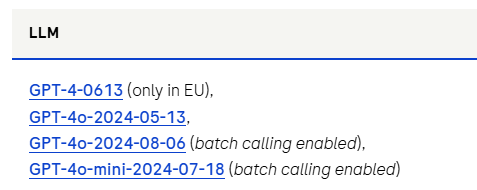

------------------------------------------
## PART 2: LLM solutions - development basics
------------------------------------------

### Add System Prompt (prompt engineering)

In [29]:
response = azure_portkey_client.chat.completions.create(
    model=azure_model,
    messages=[
        {
            "role": "system",
            "content": "You are a secondary school teacher. Please use simple language.",
        },
        {
            "role": "user",
            "content": "Explain the Transformer architecture behind LLMs in three sentences..",
        },
    ],
)
print("-"*100)
print("Message with system prompt.")
print(f"Response: {response.choices[0].message.content}")

----------------------------------------------------------------------------------------------------
Message with system prompt.
Response: The Transformer architecture is a type of neural network designed to handle sequences of data, like sentences, by processing all elements simultaneously rather than one by one. It uses self-attention mechanisms to weigh the importance of different words in a sentence when making predictions or creating translations. This approach helps the model to understand context better, making it very powerful for tasks involving language.


In [30]:
response = azure_portkey_client.chat.completions.create(
    model=azure_model,
    messages=[
        {
            "role": "system",
            "content": "You are a university teacher. Please use complex language.",
        },
        {
            "role": "user",
            "content": "Explain the Transformer architecture behind LLMs in three sentences.",
        },
    ],
)
print("-"*100)
print("Message with system prompt.")
print(f"Response: {response.choices[0].message.content}")

----------------------------------------------------------------------------------------------------
Message with system prompt.
Response: The Transformer architecture, foundational to large language models (LLMs), employs a self-attention mechanism that enables the model to weigh the significance of different tokens in a sequence relative to each other, thus capturing long-range dependencies with greater efficiency than traditional recurrent neural network structures. It consists of an encoder-decoder framework where the encoder processes the input sequence and generates context-aware representations, and the decoder utilizes these representations, in conjunction with a similar self-attention mechanism, to produce the output sequence. This paradigm shift is marked by its parallelizable nature and ability to scale, facilitating the training of extremely large models on extensive corpora, thereby enhancing their language understanding and generation capabilities.


### JSON Output

It is often crucial to have **LLMs return structured output**. This is because oftentimes the outputs of the LLMs are used in downstream applications, where specific arguments are required. Having the LLM return structured output reliably is necessary for that.

One of the methods to do this is using [Structured Outputs](https://platform.openai.com/docs/guides/structured-outputs).

Note that Structured Outputs are only supported in OpenAI models (on Azure). For AWS you can prompt the model using system prompts but the output format is not guaranteed.

In [31]:
class User(BaseModel):
    first_name: str
    surname: str
    age: int

completion = azure_portkey_client.beta.chat.completions.parse(
    model="gpt-4o-mini-2024-07-18",
    messages=[
        {"role": "user", "content": "John Doe is 30 years old."}
    ],
    response_format=User,
)

print(completion.choices[0].message.content)

{"first_name":"John","surname":"Doe","age":30}


## LLM Multimodality

Large multimodal models are large language models (LLMs) designed to **process and generate multiple modalities**, including **text, images, and sometimes audio and video**. These models are trained on large datasets containing text and image data, allowing them to learn the relationships between different modalities. Large multimodal models can be used in many ways, including image captioning, visual question answering, and content recommendation systems that use text and image data to provide personalized recommendations.

### Image Input

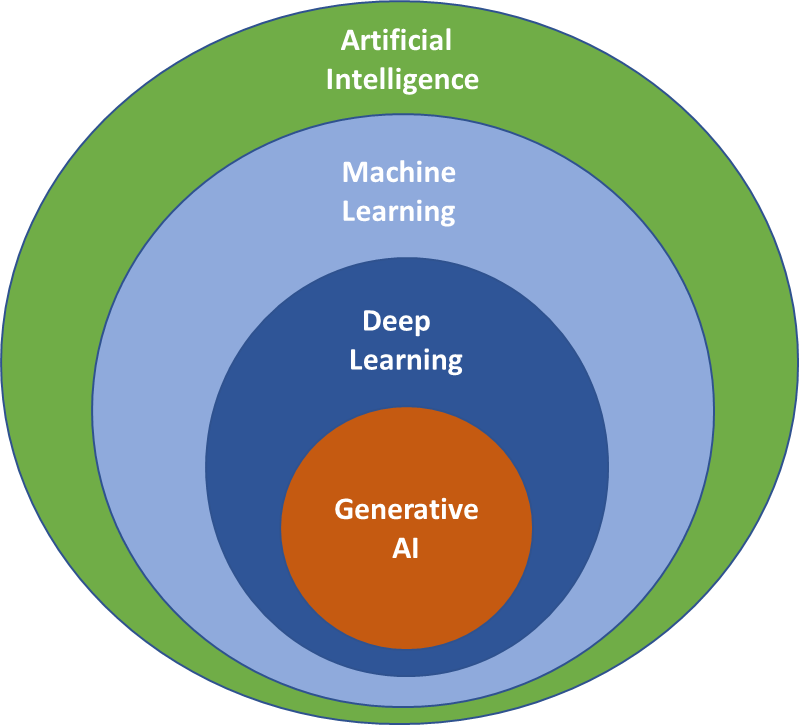

In [32]:
image_path = "genai.png"
with open(image_path, "rb") as image_file:
    image_b64 = base64.b64encode(image_file.read()).decode("utf-8") # Image needs to be passed as byte data
    image_file.seek(0)
    
display(Image(image_path, width=400)) # this line will display an image

In [33]:
response = azure_portkey_client.chat.completions.create(
        model=azure_model, # the gpt4o model accepts image data
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": "What is in this image?",
                    },
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_b64}"},
                    },
                ],
            }
        ],
        max_tokens=500,
    )

print(f"Image description: {response.choices[0].message.content}")

Image description: The image shows a Venn diagram that depicts the hierarchical relationship between various concepts in artificial intelligence. From the outside to the innermost circle, the diagram includes:

1. **Artificial Intelligence (AI)**: The broadest and most encompassing term, represented by the outermost green circle.
2. **Machine Learning (ML)**: A subset of AI, represented by the next inner light blue circle.
3. **Deep Learning (DL)**: A subset of machine learning, depicted by a darker blue circle.
4. **Generative AI**: The most specific subset, which falls under deep learning, represented by the innermost, orange circle.

This diagram visually illustrates how generative AI is a specialized area within deep learning, which is itself a more focused area within machine learning, all under the broader umbrella of artificial intelligence.


### Image Output

For this a workspace in US with AWS access is required - Stable Diffusion Model is our only current model that can generate images.

In [34]:
stable_diffusion_model = "stability.stable-diffusion-xl-v1"

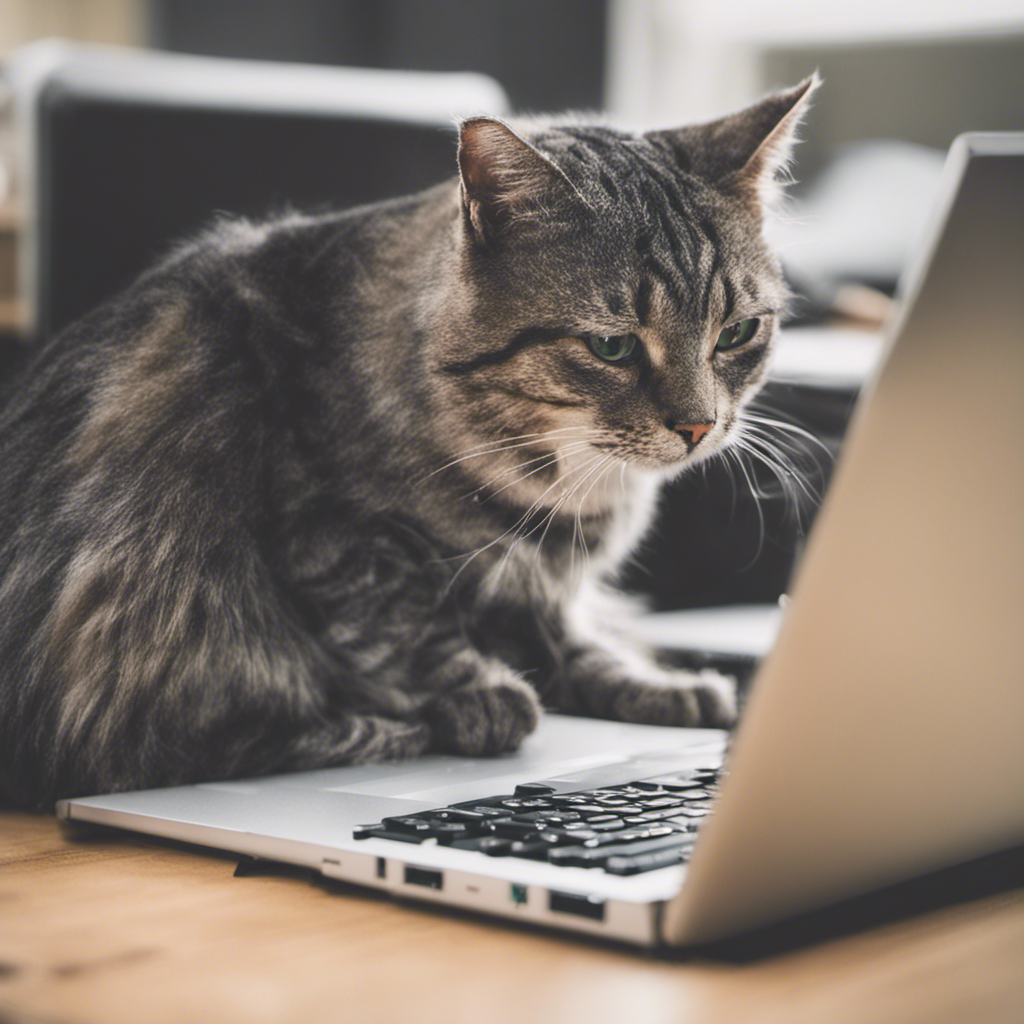

In [35]:
#stable diffusion model with AWS
image = aws_portkey_client.images.generate(
            model=stable_diffusion_model,
            prompt="A cat coding",
        )
image_bytes = base64.b64decode(image.data[0].b64_json)
display(Image(data=image_bytes))

## LLM with tool integration

Tools are interfaces that an agent, chain, or LLM can use to interact with the world. They combine a few things:

- The name of the tool
- A description of what the tool is
- JSON schema of what the inputs to the tool are
- The function to call
- Whether the result of a tool should be returned directly to the user

It is useful to have all this information because this information can be used to build action-taking systems! The name, description, and JSON schema can be used to prompt the LLM so it knows how to specify what action to take, and then the function to call is equivalent to taking that action.

Here we will create a simple calculator function that our LLM model can call if the user's query requires it

In [36]:
def calculator(operation, num1, num2):
    if operation == "add":
        return num1 + num2
    elif operation == "subtract":
        return num1 - num2
    elif operation == "multiply":
        return num1 * num2
    elif operation == "divide":
        return num1 / num2
    
calculator_tool = {
            "type": "function", #manually define the function
            "function": {
                "name": "calculator",
                "description": "Perform basic arithmetic operations",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "operation": {
                            "type": "string",
                            "enum": ["add", "subtract", "multiply", "divide"],
                            "description": "The operation to perform"
                        },
                        "num1": {
                            "type": "number",
                            "description": "The first number"
                        },
                        "num2": {
                            "type": "number",
                            "description": "The second number"
                        }
                    },
                "required": ["operation", "num1", "num2"]
                },
            },
        }

In [35]:
response = azure_portkey_client.chat.completions.create(
    model=azure_model,
    messages=[{"role": "user", "content": "WHAT IS 5 + 5?"}], # The calculator tool will be called if the LLM thinks it is useful for the query
    tools=[calculator_tool],
    tool_choice="auto",
    max_tokens=512,
)

In [37]:
def call_llm(question):
    response = azure_portkey_client.chat.completions.create(
        model=azure_model,
        messages=[{"role": "user", "content": question}], # The calculator tool will be called if the LLM thinks it is useful for the query
        tools=[calculator_tool],
        tool_choice="auto",
        max_tokens=512,
    )
    if response.choices[0].message.tool_calls:
        for tool_call in response.choices[0].message.tool_calls:
            if tool_call.function.name == "calculator":
                function_args = json.loads(tool_call.function.arguments)
                print(f"Function arguments: {function_args}")  
                answer = calculator(
                    operation=function_args.get("operation"),
                    num1=function_args.get("num1"),
                    num2=function_args.get("num2"),
                )
                print('\nResponse')
                print({
                    "tool_call_id": tool_call.id,
                    "role": "tool",
                    "name": "calculator",
                    "content": answer,
                })
    else:
        print(response.choices[0].message.content)
        print()
        print("No tool calls were made by the model.")  


call_llm("What is 5 plus 5?")

Function arguments: {'operation': 'add', 'num1': 5, 'num2': 5}

Response
{'tool_call_id': 'call_Hr6qSYDAvaA5j83Cw0RXlNHR', 'role': 'tool', 'name': 'calculator', 'content': 10}


What if the question does not contain an arithmetic problem?

In [38]:
call_llm("What is Generative AI in one sentence?")

Generative AI is a type of artificial intelligence that can create new content or data, such as text, images, or music, based on learned patterns from existing data.

No tool calls were made by the model.


## Caching

Portkey provides an optional caching layer for LLMs. This is useful for two reasons:

- It can save you money by reducing the number of API calls you make to the LLM provider, if you're often requesting the same completion multiple times.
- It can speed up your application by reducing the number of API calls you make to the LLM provider.

Caching configuration is done on the Portkey UI. Caching can be <b>simple</b> or <b>semantic</b>. 

- Simple cache performs an exact match on the input prompts. To use it simply add the following to your config:
    ```
    "cache": { "mode": "simple" }
    ```
- Semantic cache considers the contextual similarity between input requests. To use it simply add the following to your config:
    ```
    "cache": { "mode": "semantic" }
    ```

For more information see the [Portkey Caching guide](https://portkey.ai/docs/product/ai-gateway/cache-simple-and-semantic)

In [39]:
# We are using SIMPLE caching, and we've added it to AWS config

start = time.time()
response = aws_portkey_client.chat.completions.create(
    model=aws_model,
    messages=[
        {
            "role": "user",
            "content": "Describe Generative AI in three sentences",
        },
    ],
)
time_without_cache = time.time() - start
print(f"Response: {response.choices[0].message.content}")
print(f"Response time without cache: {time_without_cache}s")
print(f"Id of response: {response.id}")

Response: 

Generative AI is a type of AI that can create content such as images, text, or music that resembles human-made content. Generative AI models can be trained on large datasets of text or images and can then generate new content that is similar to the training data. This technology has been used to create everything from realistic images of people to music that sounds like a famous artist. Generative AI has the potential to revolutionize industries such as art, music, and writing by making it easier and faster to create high-quality content. However, there are also concerns about the potential for generative AI to be used for malicious
Response time without cache: 6.25262188911438s
Id of response: 1741170986744


In [40]:
start = time.time()
response_with_cache = aws_portkey_client.chat.completions.create(
    model=aws_model,
    messages=[
        {
            "role": "user",
            "content": "Describe Generative AI in three sentences",
        },
    ],
)
time_with_cache = time.time() - start
print(f"Response: {response.choices[0].message.content}")
print(f"Response time without cache: {time_with_cache}s")
print(f"Id of response: {response_with_cache.id}")

Response: 

Generative AI is a type of AI that can create content such as images, text, or music that resembles human-made content. Generative AI models can be trained on large datasets of text or images and can then generate new content that is similar to the training data. This technology has been used to create everything from realistic images of people to music that sounds like a famous artist. Generative AI has the potential to revolutionize industries such as art, music, and writing by making it easier and faster to create high-quality content. However, there are also concerns about the potential for generative AI to be used for malicious
Response time without cache: 0.7627973556518555s
Id of response: 1741170986744


In [41]:
(time_with_cache / time_without_cache) * 100

12.199639913935336

![image.png](cache.png)

## Show analytics in Portkey